# Valutazione tecniche di embedding e few-shot per riassunti con LLM (versione compatta)

Questo notebook confronta 4 tecniche di embedding (TF-IDF, SBERT multilingue, SBERT inglese, Ollama `nomic-embed-text`) e 3 valori di k (2, 4, 6) per il few-shot prompting, generando riassunti con un LLM locale via Ollama e valutandoli con ROUGE, BLEU, METEOR e BERTScore.

## Installazione librerie

Esegui una sola volta (rimuovi il commento se non le hai già installate).

In [1]:
# pip install sentence-transformers scikit-learn pyAutoSummarizer pandas tqdm requests

## Configurazione

Percorsi dei file, modello di generazione (Ollama) e modello di embedding (Ollama), parametri dell'esperimento.



In [2]:
TRAIN_PATH = "train-2.tab"
TEST_PATH = "sample_100_seed42.tsv"

DOCUMENT_COL = None   # es. "text" -- lascia None per auto-detect
SUMMARY_COL = None    # es. "highlights" -- lascia None per auto-detect
ID_COL = None
SEP = "\t"  # sia .tab che .tsv sono di norma tab-separated

# --- Modello di generazione (Ollama) ---
MODELLO = "qwen2.5:7b"                 # generation model, as pulled in Ollama
MAX_TOKENS = 400
TEMPERATURE = 0.3

OLLAMA_GENERATE_URL = "http://localhost:11434/api/generate"
OLLAMA_OPTIONS = {
    "temperature": TEMPERATURE,
    "num_predict": MAX_TOKENS,
}

# --- Modello di embedding (Ollama) ---
OLLAMA_URL = "http://localhost:11434/v1"
OLLAMA_EMBED_MODEL = "nomic-embed-text"
EMBED_CACHE_DIR = "./embed_cache"
EMBED_BATCH_SIZE = 64

# --- Metriche ---
BERT_SCORE_MODEL = "roberta-large"

# --- Esperimento ---
K_VALUES = [2, 4, 6]

## Caricamento dati

Carica `train-2.tab` e `sample_100_seed42.tsv`, auto-individuando le colonne documento/riassunto.

In [3]:
import csv as _csv
import sys as _sys
import pandas as pd

_csv.field_size_limit(_sys.maxsize)


def load_tabular_dataset(path, sep="\t", document_col=None, summary_col=None, id_col=None):
    df = pd.read_csv(path, sep=sep, engine="python", dtype=str, keep_default_na=False)
    print(f"[{path}] colonne trovate: {list(df.columns)}  (righe: {len(df)})")

    def _guess(candidates, cols):
        for c in candidates:
            if c in cols:
                return c
        return None

    cols = list(df.columns)
    doc_col = document_col or _guess(
        ["document", "documento", "text", "source", "src", "article"], cols)
    sum_col = summary_col or _guess(
        ["summary", "riassunto", "target", "reference", "highlights", "abstract"], cols)
    _id_col = id_col or _guess(["id", "ID", "index"], cols)

    if doc_col is None or sum_col is None:
        raise ValueError(
            f"Non riesco a capire quali colonne siano document/summary in {path}. "
            f"Colonne disponibili: {cols}. Specifica document_col e summary_col esplicitamente."
        )

    records = []
    for i, row in df.iterrows():
        records.append({
            "id": row[_id_col] if _id_col else i,
            "document": row[doc_col],
            "summary": row[sum_col],
        })
    return records


train_set = load_tabular_dataset(TRAIN_PATH, sep=SEP, document_col=DOCUMENT_COL,
                                  summary_col=SUMMARY_COL, id_col=ID_COL)
test_set_small = load_tabular_dataset(TEST_PATH, sep=SEP, document_col=DOCUMENT_COL,
                                       summary_col=SUMMARY_COL, id_col=ID_COL)

print(f"Training set: {len(train_set)} documenti")
print(f"Test set ridotto: {len(test_set_small)} documenti")

[train-2.tab] colonne trovate: ['document', 'summary']  (righe: 44882)
[sample_100_seed42.tsv] colonne trovate: ['row_id', 'split', 'document', 'summary']  (righe: 100)
Training set: 44882 documenti
Test set ridotto: 100 documenti


## Pipeline completa — tutte le tecniche in un'unica cella

Questa cella grande contiene tutto quello che serve per l'esperimento completo:

1. **Tecniche di embedding**: TF-IDF, SBERT multilingue, SBERT inglese, Ollama `nomic-embed-text` 
2. **Ricerca nearest neighbours** (cosine similarity)
3. **Costruzione prompt few-shot**
4. **Chiamata al modello di generazione** via Ollama
5. **Calcolo delle metriche** (ROUGE, BLEU, METEOR, BERTScore) con `pyAutoSummarizer`
6. **Loop sperimentale**: per ogni tecnica × ogni k, genera i riassunti e calcola le metriche
7. **Aggregazione e ranking** delle configurazioni (embedding, k)
8. **Salvataggio** di tutti i risultati in CSV

⚠️ Può richiedere molto tempo: genera `4 tecniche × 3 valori di k × N documenti di test` riassunti con l'LLM.

In [5]:
import os
import hashlib
import pickle
import numpy as np
import requests
from dataclasses import dataclass, field
from typing import List, Dict, Any

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

import pyAutoSummarizer.base as psr
from tqdm import tqdm


# =========================================================================
# 1. TECNICHE DI EMBEDDING
# =========================================================================

class EmbeddingTechnique:
    def __init__(self, name: str):
        self.name = name

    def fit(self, train_texts: List[str]):
        pass

    def encode(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class TfidfEmbedding(EmbeddingTechnique):
    def __init__(self):
        super().__init__("tfidf")
        self.vectorizer = TfidfVectorizer(max_features=20000)

    def fit(self, train_texts: List[str]):
        self.vectorizer.fit(train_texts)

    def encode(self, texts: List[str]) -> np.ndarray:
        return self.vectorizer.transform(texts).toarray()


class SBERTEmbedding(EmbeddingTechnique):
    def __init__(self, model_name: str, tag: str):
        super().__init__(tag)
        from sentence_transformers import SentenceTransformer
        self.model = SentenceTransformer(model_name)

    def encode(self, texts: List[str]) -> np.ndarray:
        return self.model.encode(texts, show_progress_bar=False, normalize_embeddings=True)


class OllamaEmbedding(EmbeddingTechnique):
    def __init__(self, model_name: str = OLLAMA_EMBED_MODEL, tag: str = "ollama_nomic_embed",
                 base_url: str = OLLAMA_URL, batch_size: int = EMBED_BATCH_SIZE,
                 cache_dir: str = EMBED_CACHE_DIR):
        super().__init__(tag)
        self.model_name = model_name
        self.url = f"{base_url}/embeddings"
        self.batch_size = batch_size
        self.cache_dir = cache_dir
        os.makedirs(self.cache_dir, exist_ok=True)

    def _cache_path(self, text: str) -> str:
        key = hashlib.sha256(f"{self.model_name}::{text}".encode("utf-8")).hexdigest()
        return os.path.join(self.cache_dir, f"{key}.pkl")

    def _load_cached(self, text: str):
        path = self._cache_path(text)
        if os.path.exists(path):
            with open(path, "rb") as f:
                return pickle.load(f)
        return None

    def _save_cache(self, text: str, vector: List[float]):
        with open(self._cache_path(text), "wb") as f:
            pickle.dump(vector, f)

    def _embed_batch(self, batch: List[str]) -> List[List[float]]:
        resp = requests.post(self.url, json={"model": self.model_name, "input": batch}, timeout=300)
        if resp.status_code != 200:
            print(f"Errore embedding batch: status {resp.status_code}")
            print(f"Risposta Ollama: {resp.text}")
            resp.raise_for_status()
        data = resp.json()["data"]
        return [item["embedding"] for item in data]

    def encode(self, texts: List[str]) -> np.ndarray:
        vectors = [None] * len(texts)
        to_fetch_idx, to_fetch_texts = [], []

        for i, text in enumerate(texts):
            cached = self._load_cached(text)
            if cached is not None:
                vectors[i] = cached
            else:
                to_fetch_idx.append(i)
                to_fetch_texts.append(text)

        for start in tqdm(range(0, len(to_fetch_texts), self.batch_size),
                           desc=f"Embedding ({self.name})"):
            batch = to_fetch_texts[start:start + self.batch_size]
            batch_idx = to_fetch_idx[start:start + self.batch_size]
            batch_vectors = self._embed_batch(batch)
            for idx, text, vec in zip(batch_idx, batch, batch_vectors):
                vectors[idx] = vec
                self._save_cache(text, vec)

        return np.array(vectors)


def build_embedding_techniques() -> List[EmbeddingTechnique]:
    return [
        TfidfEmbedding(),
        SBERTEmbedding("paraphrase-multilingual-mpnet-base-v2", "sbert_multilingual_mpnet"),
        SBERTEmbedding("all-mpnet-base-v2", "sbert_mpnet_en"),
        OllamaEmbedding(OLLAMA_EMBED_MODEL, "ollama_nomic_embed"),
    ]


# =========================================================================
# 2. NEAREST NEIGHBOURS
# =========================================================================

def get_nearest_neighbours(train_embeddings: np.ndarray, test_embeddings: np.ndarray, k: int) -> np.ndarray:
    nn = NearestNeighbors(n_neighbors=k, metric="cosine")
    nn.fit(train_embeddings)
    _, indices = nn.kneighbors(test_embeddings)
    return indices


# =========================================================================
# 3. PROMPT FEW-SHOT
# =========================================================================

def build_fewshot_prompt(neighbour_examples: List[Dict[str, str]], target_document: str) -> str:
    blocks = []
    for ex in neighbour_examples:
        blocks.append(f"Document:\n{ex['document']}\n\nSummary:\n{ex['summary']}\n")
    examples_text = "\n---\n".join(blocks)

    prompt = (
        "You are an helpful assistant that summarizes newsarticles from different sources.\n\n"
        "You will be shown k examples with documents and summaries human generated. You will have then create a summary resembling the style of the ones human generated without mixing the example sources with your own document.\n\n"
        f"{examples_text}\n---\n"
        f"The document you need to summarise is the following:\n{target_document}\n\nSummary:"
    )
    return prompt


# =========================================================================
# 4. CHIAMATA AL MODELLO DI GENERAZIONE (Ollama)
# =========================================================================

def call_llm(prompt: str, model: str = None) -> str:
    payload = {
        "model": model or MODELLO,
        "prompt": prompt,
        "stream": False,
        "options": OLLAMA_OPTIONS,
    }
    resp = requests.post(OLLAMA_GENERATE_URL, json=payload, timeout=300)
    resp.raise_for_status()
    return resp.json()["response"].strip()


# =========================================================================
# 5. METRICHE (pyAutoSummarizer)
# =========================================================================

_scorer = psr.summarization(
    "placeholder", stop_words=['en'], lowercase=True,
    rmv_accents=True, rmv_special_chars=True, rmv_numbers=True,
)

_METRIC_COLS = [
    "rouge1_f1", "rouge1_p", "rouge1_r",
    "rouge2_f1", "rouge2_p", "rouge2_r",
    "rougeL_f1", "rougeL_p", "rougeL_r",
    "bleu", "meteor",
    "bertscore_f1", "bertscore_p", "bertscore_r",
]


def _empty_metrics() -> Dict[str, float]:
    return {col: None for col in _METRIC_COLS}


def compute_metrics(prediction: str, reference: str, doc_index=None) -> Dict[str, float]:
    if not isinstance(prediction, str) or prediction.startswith("Error:") or not prediction.strip():
        return _empty_metrics()

    try:
        r1_f1, r1_p, r1_r = _scorer.rouge_N(prediction, reference, n=1)
        r2_f1, r2_p, r2_r = _scorer.rouge_N(prediction, reference, n=2)
        rl_f1, rl_p, rl_r = _scorer.rouge_L(prediction, reference)
        bleu_score = _scorer.bleu(prediction, reference, n=4)
        meteor_score = _scorer.meteor(prediction, reference)
        bs_f1, bs_p, bs_r = _scorer.bert_score(prediction, reference, model_type=BERT_SCORE_MODEL)

        return {
            "rouge1_f1": r1_f1, "rouge1_p": r1_p, "rouge1_r": r1_r,
            "rouge2_f1": r2_f1, "rouge2_p": r2_p, "rouge2_r": r2_r,
            "rougeL_f1": rl_f1, "rougeL_p": rl_p, "rougeL_r": rl_r,
            "bleu": bleu_score, "meteor": meteor_score,
            "bertscore_f1": bs_f1, "bertscore_p": bs_p, "bertscore_r": bs_r,
        }
    except Exception as e:
        label = f"documento {doc_index}" if doc_index is not None else "documento"
        print(f"Errore nel calcolo delle metriche per {label}: {e}")
        return _empty_metrics()


# =========================================================================
# 6. LOOP SPERIMENTALE
# =========================================================================

@dataclass
class ExperimentResult:
    embedding: str
    k: int
    per_doc: List[Dict[str, Any]] = field(default_factory=list)

    def to_summary_row(self) -> Dict[str, Any]:
        df = pd.DataFrame(self.per_doc)
        row = {"embedding": self.embedding, "k": self.k}
        row["n_scored"] = df[_METRIC_COLS].notna().all(axis=1).sum()
        row["n_total"] = len(df)
        for col in _METRIC_COLS:
            row[f"{col}_mean"] = df[col].mean(skipna=True)
            row[f"{col}_std"] = df[col].std(skipna=True)
        return row


def run_experiment(train_set, test_set_small, k_values=(2, 4, 6)):
    train_docs = [d["document"] for d in train_set]
    train_summaries = [d["summary"] for d in train_set]
    test_docs = [d["document"] for d in test_set_small]
    test_references = [d["summary"] for d in test_set_small]

    techniques = build_embedding_techniques()
    all_results: List[ExperimentResult] = []

    for technique in techniques:
        print(f"\n=== Embedding: {technique.name} ===")
        technique.fit(train_docs)
        train_emb = technique.encode(train_docs)
        test_emb = technique.encode(test_docs)

        for k in k_values:
            print(f"  -- k={k} --")
            neighbour_idx = get_nearest_neighbours(train_emb, test_emb, k)

            per_doc_metrics = []
            for i, test_doc in enumerate(tqdm(test_docs, desc=f"{technique.name} | k={k}")):
                examples = [
                    {"document": train_docs[j], "summary": train_summaries[j]}
                    for j in neighbour_idx[i]
                ]
                prompt = build_fewshot_prompt(examples, test_doc)

                try:
                    prediction = call_llm(prompt)
                except Exception as e:
                    prediction = f"Error: {e}"

                reference = test_references[i]
                metrics = compute_metrics(prediction, reference, doc_index=i)
                per_doc_metrics.append({
                    "id": test_set_small[i].get("id", i),
                    **metrics,
                    "generated_summary": prediction,
                    "reference_summary": reference,
                })

            all_results.append(ExperimentResult(embedding=technique.name, k=k, per_doc=per_doc_metrics))

    summary_df = pd.DataFrame([r.to_summary_row() for r in all_results])
    return summary_df, all_results


# =========================================================================
# 7. RANKING DELLE CONFIGURAZIONI
# =========================================================================

def rank_configurations(summary_df: pd.DataFrame, weights: Dict[str, float] = None) -> pd.DataFrame:
    if weights is None:
        weights = {
            "rouge1_f1_mean": 0.15, "rouge2_f1_mean": 0.15, "rougeL_f1_mean": 0.15,
            "bleu_mean": 0.15, "meteor_mean": 0.15, "bertscore_f1_mean": 0.25,
        }

    df = summary_df.copy()
    for col in weights:
        col_min, col_max = df[col].min(), df[col].max()
        df[col + "_norm"] = (df[col] - col_min) / (col_max - col_min + 1e-9)

    df["composite_score"] = sum(df[col + "_norm"] * w for col, w in weights.items())
    return df.sort_values("composite_score", ascending=False)


# =========================================================================
# 8. ESECUZIONE + SALVATAGGIO
# =========================================================================

summary_df, raw_results = run_experiment(train_set, test_set_small, k_values=K_VALUES)
ranked = rank_configurations(summary_df)

print("\n=== Risultati aggregati ===")
print(summary_df.to_string(index=False))

print("\n=== Ranking finale ===")
print(ranked[["embedding", "k", "n_scored", "n_total", "composite_score"]].to_string(index=False))

summary_df.to_csv("summary_results.csv", index=False)
ranked.to_csv("ranked_configurations.csv", index=False)
print("\nSalvati: summary_results.csv, ranked_configurations.csv")

ranked[["embedding", "k", "n_scored", "n_total", "composite_score"]]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9167.53it/s]



=== Embedding: tfidf ===
  -- k=2 --


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 10301.38it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 10836.34it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UN

  -- k=4 --


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 10593.05it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 24948.15it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UN

...

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 25433.10it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 24772.40it/s]/it]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      

  -- k=6 --


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 26313.75it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 24821.39it/s]/it]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      


=== Risultati aggregati ===
               embedding  k  n_scored  n_total  rouge1_f1_mean  rouge1_f1_std  rouge1_p_mean  rouge1_p_std  rouge1_r_mean  rouge1_r_std  rouge2_f1_mean  rouge2_f1_std  rouge2_p_mean  rouge2_p_std  rouge2_r_mean  rouge2_r_std  rougeL_f1_mean  rougeL_f1_std  rougeL_p_mean  rougeL_p_std  rougeL_r_mean  rougeL_r_std  bleu_mean  bleu_std  meteor_mean  meteor_std  bertscore_f1_mean  bertscore_f1_std  bertscore_p_mean  bertscore_p_std  bertscore_r_mean  bertscore_r_std
                   tfidf  2       100      100        0.291502       0.090785       0.346698      0.123957       0.260799      0.088115        0.085396       0.053274       0.102082      0.066421       0.076751      0.051014        0.172940       0.059413       0.206906      0.083428       0.155534      0.058568   0.069637  0.035916     0.271419    0.086500           0.860891          0.018437          0.872793         0.023001          0.849535         0.018983
                   tfidf  4       100

,embedding,k,n_scored,n_total,composite_score
6,sbert_mpnet_en,2,100,100,0.900817
10,ollama_nomic_embed,4,100,100,0.771020
0,tfidf,2,100,100,0.733429
7,sbert_mpnet_en,4,100,100,0.701986
9,ollama_nomic_embed,2,100,100,0.687173
3,sbert_multilingual_mpnet,2,100,100,0.569269
1,tfidf,4,100,100,0.539501
5,sbert_multilingual_mpnet,6,100,100,0.473695
11,ollama_nomic_embed,6,100,100,0.392555
4,sbert_multilingual_mpnet,4,100,100,0.260300


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7121.36it/s]



=== Embedding: tfidf ===
  [tfidf] embeddings caricati dalla cache


tfidf | k=2: 100%|██████████| 100/100 [00:01<00:00, 61.53it/s]
tfidf | k=4:  21%|██        | 21/100 [00:00<00:03, 21.16it/s][transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (146088 > 131072). Running this sequence through the model will result in indexing errors
tfidf | k=4: 100%|██████████| 100/100 [00:03<00:00, 25.30it/s]
tfidf | k=6: 100%|██████████| 100/100 [00:05<00:00, 17.76it/s]



=== Embedding: sbert_multilingual_mpnet ===
  [sbert_multilingual_mpnet] embeddings caricati dalla cache


sbert_multilingual_mpnet | k=2: 100%|██████████| 100/100 [00:01<00:00, 96.26it/s]
sbert_multilingual_mpnet | k=4: 100%|██████████| 100/100 [00:01<00:00, 57.82it/s]
sbert_multilingual_mpnet | k=6: 100%|██████████| 100/100 [00:02<00:00, 40.79it/s]



=== Embedding: sbert_mpnet_en ===
  [sbert_mpnet_en] embeddings caricati dalla cache


sbert_mpnet_en | k=2: 100%|██████████| 100/100 [00:01<00:00, 99.01it/s]
sbert_mpnet_en | k=4: 100%|██████████| 100/100 [00:01<00:00, 55.40it/s]
sbert_mpnet_en | k=6: 100%|██████████| 100/100 [00:02<00:00, 38.56it/s]



=== Embedding: ollama_nomic_embed ===
  [ollama_nomic_embed] embeddings caricati dalla cache


ollama_nomic_embed | k=2: 100%|██████████| 100/100 [00:01<00:00, 87.69it/s]
ollama_nomic_embed | k=4: 100%|██████████| 100/100 [00:01<00:00, 52.90it/s]
ollama_nomic_embed | k=6: 100%|██████████| 100/100 [00:02<00:00, 37.55it/s]



=== Riepilogo token per combinazione (embedding, k) ===
               embedding  k     avg  median  min    max      p95
      ollama_nomic_embed  2  8437.0  6456.0  588  71720  18301.0
      ollama_nomic_embed  4 14054.0 11969.0 1326  77689  28855.0
      ollama_nomic_embed  6 19853.0 17162.0 2113  82743  36941.0
          sbert_mpnet_en  2  7433.0  6385.0  588  24808  15618.0
          sbert_mpnet_en  4 13361.0 11778.0 1326  32572  28007.0
          sbert_mpnet_en  6 19178.0 16470.0 2026  83253  36269.0
sbert_multilingual_mpnet  2  7635.0  6452.0  688  29631  15995.0
sbert_multilingual_mpnet  4 12788.0 11723.0 3663  35067  23402.0
sbert_multilingual_mpnet  6 17938.0 16726.0 4301  42094  28953.0
                   tfidf  2 11724.0  8480.0  588 103936  22976.0
                   tfidf  4 26833.0 17428.0 1338 146088 111469.0
                   tfidf  6 40780.0 25721.0 2232 185719 131420.0

Salvati: prompt_token_counts_summary.csv, prompt_token_counts_per_doc.csv


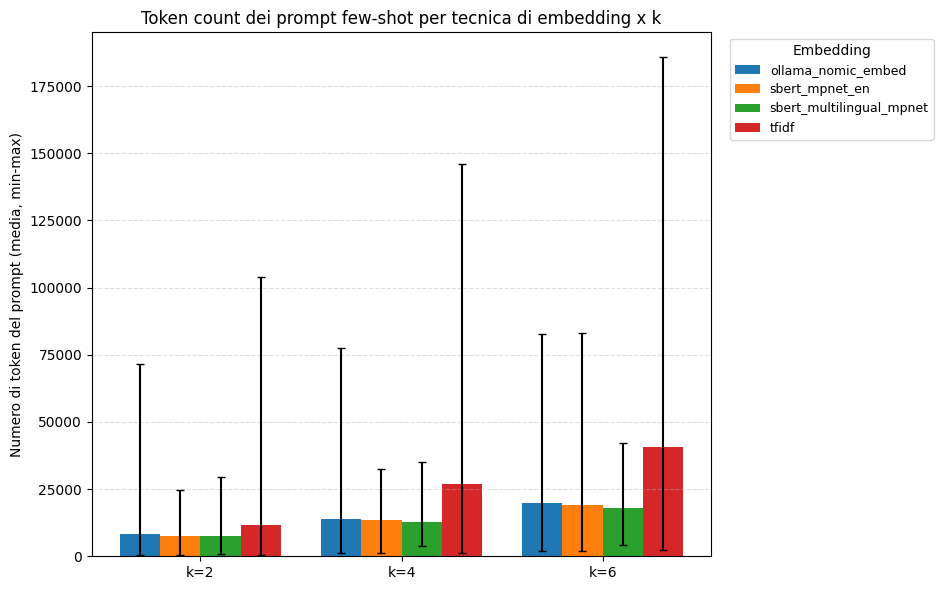

/var/folders/wc/lmk39_nj6vb165y5gdr58gqh0000gn/T/ipykernel_26576/1341060381.py:152: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)


Text(0.5, 1.0, 'Distribuzione token dei prompt')

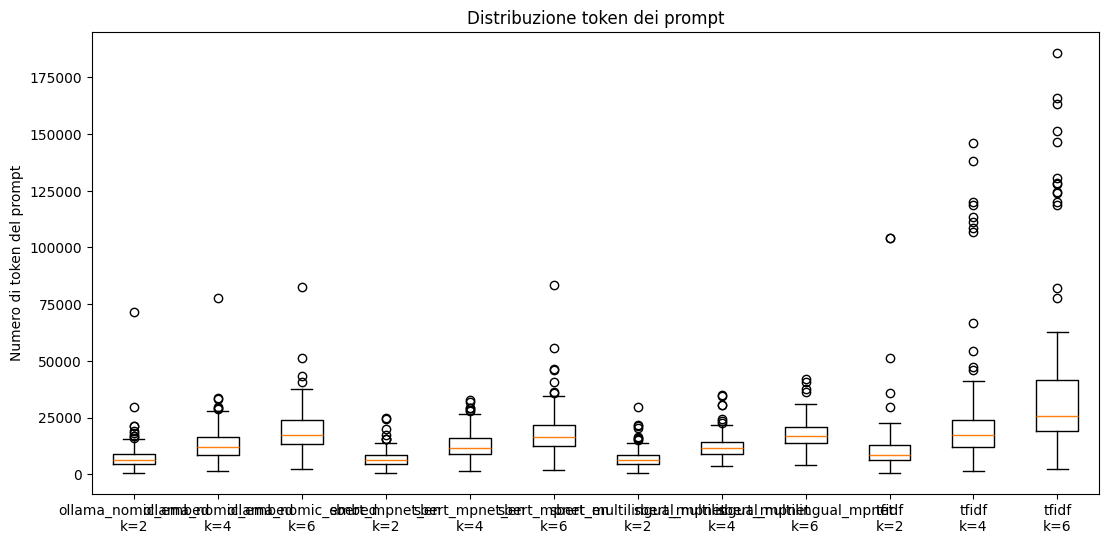

In [6]:
# =========================================================================
#ipotesi: i few-shots prompts sono troppo lunghi rispetto alla capacità del modello? 

# Conteggio token dei prompt few-shot, per tecnica di embedding x k
# con caching su disco degli embedding (non ricalcolati ad ogni run)
# + visualizzazione grafica del numero di token per prompt
# — nessuna chiamata LLM, nessuna metrica: solo retrieval + token count
# =========================================================================

import os
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from tqdm import tqdm

_tok_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")

def _count_tokens(text):
    return len(_tok_tokenizer.encode(text))


# ---- cache su disco per gli array di embedding completi ----
EMB_ARRAY_CACHE_DIR = "./embedding_arrays_cache"
os.makedirs(EMB_ARRAY_CACHE_DIR, exist_ok=True)


def _dataset_fingerprint(texts):
    """Hash del contenuto testuale, per invalidare automaticamente la cache
    se train_set/test_set_small cambiano."""
    joined = "||".join(texts)
    return hashlib.sha256(joined.encode("utf-8")).hexdigest()[:16]


def get_or_compute_embeddings(technique, train_docs, test_docs, cache_dir=EMB_ARRAY_CACHE_DIR):
    """
    Ritorna (train_emb, test_emb) per questa tecnica, caricandoli dalla cache
    su disco se già presenti, altrimenti calcolandoli una volta e salvandoli.
    """
    fp = _dataset_fingerprint(train_docs + test_docs)
    train_path = os.path.join(cache_dir, f"{technique.name}_{fp}_train.npy")
    test_path = os.path.join(cache_dir, f"{technique.name}_{fp}_test.npy")

    if os.path.exists(train_path) and os.path.exists(test_path):
        print(f"  [{technique.name}] embeddings caricati dalla cache")
        return np.load(train_path), np.load(test_path)

    print(f"  [{technique.name}] calcolo embeddings (non ancora in cache)...")
    technique.fit(train_docs)
    train_emb = technique.encode(train_docs)
    test_emb = technique.encode(test_docs)

    np.save(train_path, train_emb)
    np.save(test_path, test_emb)
    return train_emb, test_emb


def measure_prompt_tokens(train_set, test_set_small, k_values=(2, 4, 6)):
    """
    Per ogni tecnica di embedding (da build_embedding_techniques()) e ogni k,
    calcola i nearest neighbours, costruisce il prompt few-shot esatto
    (build_fewshot_prompt) per ogni documento di test, e conta i token.
    Ritorna un DataFrame lungo (embedding, k, doc_index, n_tokens).
    """
    train_docs = [d["document"] for d in train_set]
    train_summaries = [d["summary"] for d in train_set]
    test_docs = [d["document"] for d in test_set_small]

    techniques = build_embedding_techniques()
    rows = []

    for technique in techniques:
        print(f"\n=== Embedding: {technique.name} ===")
        train_emb, test_emb = get_or_compute_embeddings(technique, train_docs, test_docs)

        for k in k_values:
            neighbour_idx = get_nearest_neighbours(train_emb, test_emb, k)

            for i, test_doc in enumerate(tqdm(test_docs, desc=f"{technique.name} | k={k}")):
                examples = [
                    {"document": train_docs[j], "summary": train_summaries[j]}
                    for j in neighbour_idx[i]
                ]
                prompt = build_fewshot_prompt(examples, test_doc)
                rows.append({
                    "embedding": technique.name,
                    "k": k,
                    "doc_index": i,
                    "n_tokens": _count_tokens(prompt),
                })

    return pd.DataFrame(rows)


token_df = measure_prompt_tokens(train_set, test_set_small, k_values=K_VALUES)

# ---- tabella riassuntiva: media / mediana / max / p95 per combinazione ----
token_summary = (
    token_df.groupby(["embedding", "k"])["n_tokens"]
    .agg(avg="mean", median="median", min="min", max="max",
         p95=lambda s: s.quantile(0.95))
    .round(0)
    .reset_index()
)
print("\n=== Riepilogo token per combinazione (embedding, k) ===")
print(token_summary.to_string(index=False))

token_summary.to_csv("prompt_token_counts_summary.csv", index=False)
token_df.to_csv("prompt_token_counts_per_doc.csv", index=False)
print("\nSalvati: prompt_token_counts_summary.csv, prompt_token_counts_per_doc.csv")


# =========================================================================
# Visualizzazione
# =========================================================================

embeddings = token_summary["embedding"].unique()
k_values_sorted = sorted(token_summary["k"].unique())

# ---- grafico a barre: token medi (con barre di errore = min/max) ----
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(k_values_sorted))
width = 0.8 / max(len(embeddings), 1)

for i, emb_name in enumerate(embeddings):
    sub = token_summary[token_summary["embedding"] == emb_name].set_index("k").reindex(k_values_sorted)
    avg_vals = sub["avg"].values
    err_low = avg_vals - sub["min"].values
    err_high = sub["max"].values - avg_vals
    ax.bar(x + i * width, avg_vals, width, label=emb_name,
           yerr=[err_low, err_high], capsize=3)

ax.set_xticks(x + width * (len(embeddings) - 1) / 2)
ax.set_xticklabels([f"k={k}" for k in k_values_sorted])
ax.set_ylabel("Numero di token del prompt (media, min-max)")
ax.set_title("Token count dei prompt few-shot per tecnica di embedding x k")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title="Embedding")
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

# ---- boxplot: distribuzione completa dei token per combinazione ----
fig, ax = plt.subplots(figsize=(13, 6))
labels, data = [], []
for emb_name in embeddings:
    for k in k_values_sorted:
        vals = token_df[(token_df["embedding"] == emb_name) & (token_df["k"] == k)]["n_tokens"]
        labels.append(f"{emb_name}\nk={k}")
        data.append(vals.values)

ax.boxplot(data, labels=labels, showfliers=True)
ax.set_ylabel("Numero di token del prompt")
ax.set_title("Distribuzione token dei prompt")

In [ ]:
# =========================================================================
# Confronto a 3: prompt "old" vs "new" (migliorato) vs "structured"
# (con sezioni esplicite e tag), su 10 campioni, stessa tecnica/k
# =========================================================================

import random

random.seed(42)

N_TEST_DOCS = 10
TEST_EMBEDDING = "ollama_nomic_embed"
TEST_K = 2


def build_fewshot_prompt_old(neighbour_examples, target_document):
    blocks = []
    for ex in neighbour_examples:
        blocks.append(f"Document:\n{ex['document']}\n\nSummary:\n{ex['summary']}\n")
    examples_text = "\n---\n".join(blocks)

    return (
        "You are an helpful assistant that summarizes newsarticles from different sources.\n\n"
        "You will be shown k examples with documents and summaries human generated. You will have then create a summary resembling the style of the ones human generated without mixing the example sources with your own document.\n\n"
        f"{examples_text}\n---\n"
        f"The document you need to summarise is the following:\n{target_document}\n\nSummary:"
    )


def build_fewshot_prompt_new(neighbour_examples, target_document):
    n = len(neighbour_examples)
    blocks = []
    for i, ex in enumerate(neighbour_examples, 1):
        blocks.append(f"--- Example {i} ---\nArticle:\n{ex['document']}\n\nSummary:\n{ex['summary']}")
    examples_text = "\n\n".join(blocks)

    return (
        "You are a professional news editor who writes concise, accurate summaries.\n\n"
        f"Below are {n} example pairs of (article -> human-written summary). "
        "Study their length, tone, and level of detail closely — your summary must match this style.\n\n"
        f"{examples_text}\n\n"
        "=== New article to summarize ===\n"
        f"{target_document}\n\n"
        "Instructions:\n"
        f"- Write a summary of ONLY the article above, matching the style and approximate length of the {n} example summaries.\n"
        "- Do not include any facts, names, or details from the example articles — only from the new article.\n"
        "- Do not add a title, preamble, or explanation — output ONLY the summary text itself.\n\n"
        "Summary:"
    )


def build_fewshot_prompt_structured(neighbour_examples, target_document):
    n = len(neighbour_examples)
    example_blocks = []
    for i, ex in enumerate(neighbour_examples, 1):
        example_blocks.append(
            f"<example id=\"{i}\">\n"
            f"<article>\n{ex['document']}\n</article>\n"
            f"<summary>\n{ex['summary']}\n</summary>\n"
            f"</example>"
        )
    examples_text = "\n\n".join(example_blocks)

    return (
        "# Task\n"
        "You are a professional news editor. Your job is to write a concise, accurate summary "
        "of a news article, matching the style of human-written reference summaries.\n\n"
        "# Reference examples\n"
        f"The {n} examples below show the expected summary style (length, tone, level of detail). "
        "Do not copy or reuse any facts from these example articles — they are for style guidance only.\n\n"
        f"{examples_text}\n\n"
        "# Target article\n"
        f"<article>\n{target_document}\n</article>\n\n"
        "# Constraints\n"
        f"1. Summarize ONLY the content inside the <article> tag above — no facts from the examples.\n"
        f"2. Match the length and tone of the {n} example summaries shown above.\n"
        "3. Output must contain ONLY the summary text — no title, no preamble, no explanation, no markdown.\n\n"
        "# Output\n"
        "Summary:"
    )


PROMPT_VARIANTS = {
    "old": build_fewshot_prompt_old,
    "new": build_fewshot_prompt_new,
    "structured": build_fewshot_prompt_structured,
}


# ---- setup: stessa tecnica/k e stesso campione per tutte e 3 le varianti ----
train_docs = [d["document"] for d in train_set]
train_summaries = [d["summary"] for d in train_set]
test_docs = [d["document"] for d in test_set_small]
test_references = [d["summary"] for d in test_set_small]

technique = next(t for t in build_embedding_techniques() if t.name == TEST_EMBEDDING)
train_emb, test_emb = get_or_compute_embeddings(technique, train_docs, test_docs)
neighbour_idx = get_nearest_neighbours(train_emb, test_emb, TEST_K)

sampled_docs = random.sample(range(len(test_docs)), min(N_TEST_DOCS, len(test_docs)))

rows = []
for doc_i in tqdm(sampled_docs, desc=f"3-way prompt test ({TEST_EMBEDDING}, k={TEST_K})"):
    examples = [
        {"document": train_docs[j], "summary": train_summaries[j]}
        for j in neighbour_idx[doc_i]
    ]
    reference = test_references[doc_i]

    for variant_name, builder in PROMPT_VARIANTS.items():
        prompt = builder(examples, test_docs[doc_i])
        try:
            prediction = call_llm(prompt)
        except Exception as e:
            prediction = f"Error: {e}"

        metrics = compute_metrics(prediction, reference, doc_index=doc_i)
        rows.append({
            "doc_index": doc_i,
            "prompt_variant": variant_name,
            **metrics,
            "generated_summary": prediction,
            "reference_summary": reference,
        })

prompt_comparison_df = pd.DataFrame(rows)

# ---- confronto medie tra le 3 varianti ----
print(f"\n=== Confronto old vs new vs structured ({N_TEST_DOCS} documenti, {TEST_EMBEDDING}, k={TEST_K}) ===")
comparison = prompt_comparison_df.groupby("prompt_variant")[_METRIC_COLS].mean(numeric_only=True).round(4)
print(comparison.reindex(["old", "new", "structured"]))

prompt_comparison_df.to_csv("prompt_variants_comparison.csv", index=False)
print("\nSalvato: prompt_variants_comparison.csv (include i testi generati per ispezione manuale)")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9109.30it/s]


  [ollama_nomic_embed] embeddings caricati dalla cache


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 10534.64it/s]0:00<?, ?it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 24927.95it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bi


=== Confronto old vs new vs structured (10 documenti, ollama_nomic_embed, k=4) ===
                rouge1_f1  rouge1_p  rouge1_r  rouge2_f1  rouge2_p  rouge2_r  \
prompt_variant                                                                 
old                0.3545    0.4400    0.3130     0.1120    0.1387    0.0994   
new                0.3281    0.4421    0.2709     0.0955    0.1368    0.0767   
structured         0.3235    0.4867    0.2508     0.1092    0.1708    0.0836   

                rougeL_f1  rougeL_p  rougeL_r    bleu  meteor  bertscore_f1  \
prompt_variant                                                                
old                0.2066    0.2542    0.1845  0.0815  0.3126        0.8754   
new                0.1916    0.2688    0.1547  0.0662  0.2664        0.8765   
structured         0.2034    0.3277    0.1523  0.0580  0.2376        0.8729   

                bertscore_p  bertscore_r  
prompt_variant                            
old                  0.8881      

In [9]:
# =========================================================================
# Confronto: 3 varianti di prompt (old / new / structured)
#            x 3 tecniche di embedding (tfidf, sbert_mpnet_en = "Bert", "ollama_nomic_embed")
# su 10 campioni, stesso k
# =========================================================================

import random

random.seed(42)

N_TEST_DOCS = 100
TEST_EMBEDDINGS = ["tfidf", "sbert_mpnet_en", "ollama_nomic_embed"]   # "Bert" = SBERT su all-mpnet-base-v2
TEST_K = 2


def build_fewshot_prompt_old(neighbour_examples, target_document):
    blocks = []
    for ex in neighbour_examples:
        blocks.append(f"Document:\n{ex['document']}\n\nSummary:\n{ex['summary']}\n")
    examples_text = "\n---\n".join(blocks)

    return (
        "You are an helpful assistant that summarizes newsarticles from different sources.\n\n"
        "You will be shown k examples with documents and summaries human generated. You will have then create a summary resembling the style of the ones human generated without mixing the example sources with your own document.\n\n"
        f"{examples_text}\n---\n"
        f"The document you need to summarise is the following:\n{target_document}\n\nSummary:"
    )


def build_fewshot_prompt_new(neighbour_examples, target_document):
    n = len(neighbour_examples)
    blocks = []
    for i, ex in enumerate(neighbour_examples, 1):
        blocks.append(f"--- Example {i} ---\nArticle:\n{ex['document']}\n\nSummary:\n{ex['summary']}")
    examples_text = "\n\n".join(blocks)

    return (
        "You are a professional news editor who writes concise, accurate summaries.\n\n"
        f"Below are {n} example pairs of (article -> human-written summary). "
        "Study their length, tone, and level of detail closely — your summary must match this style.\n\n"
        f"{examples_text}\n\n"
        "=== New article to summarize ===\n"
        f"{target_document}\n\n"
        "Instructions:\n"
        f"- Write a summary of ONLY the article above, matching the style and approximate length of the {n} example summaries.\n"
        "- Do not include any facts, names, or details from the example articles — only from the new article.\n"
        "- Do not add a title, preamble, or explanation — output ONLY the summary text itself.\n\n"
        "Summary:"
    )


def build_fewshot_prompt_structured(neighbour_examples, target_document):
    n = len(neighbour_examples)
    example_blocks = []
    for i, ex in enumerate(neighbour_examples, 1):
        example_blocks.append(
            f"<example id=\"{i}\">\n"
            f"<article>\n{ex['document']}\n</article>\n"
            f"<summary>\n{ex['summary']}\n</summary>\n"
            f"</example>"
        )
    examples_text = "\n\n".join(example_blocks)

    return (
        "# Task\n"
        "You are a professional news editor. Your job is to write a concise, accurate summary "
        "of a news article, matching the style of human-written reference summaries.\n\n"
        "# Reference examples\n"
        f"The {n} examples below show the expected summary style (length, tone, level of detail). "
        "Do not copy or reuse any facts from these example articles — they are for style guidance only.\n\n"
        f"{examples_text}\n\n"
        "# Target article\n"
        f"<article>\n{target_document}\n</article>\n\n"
        "# Constraints\n"
        f"1. Summarize ONLY the content inside the <article> tag above — no facts from the examples.\n"
        f"2. Match the length and tone of the {n} example summaries shown above.\n"
        "3. Output must contain ONLY the summary text — no title, no preamble, no explanation, no markdown.\n\n"
        "# Output\n"
        "Summary:"
    )


PROMPT_VARIANTS = {
    "old": build_fewshot_prompt_old,
    "new": build_fewshot_prompt_new,
    "structured": build_fewshot_prompt_structured,
}


# ---- setup: stesso campione di documenti per tutte le combinazioni ----
train_docs = [d["document"] for d in train_set]
train_summaries = [d["summary"] for d in train_set]
test_docs = [d["document"] for d in test_set_small]
test_references = [d["summary"] for d in test_set_small]

sampled_docs = random.sample(range(len(test_docs)), min(N_TEST_DOCS, len(test_docs)))

all_techniques = {t.name: t for t in build_embedding_techniques()}

rows = []
for emb_name in TEST_EMBEDDINGS:
    technique = all_techniques[emb_name]
    train_emb, test_emb = get_or_compute_embeddings(technique, train_docs, test_docs)
    neighbour_idx = get_nearest_neighbours(train_emb, test_emb, TEST_K)

    for doc_i in tqdm(sampled_docs, desc=f"{emb_name} | k={TEST_K}"):
        examples = [
            {"document": train_docs[j], "summary": train_summaries[j]}
            for j in neighbour_idx[doc_i]
        ]
        reference = test_references[doc_i]

        for variant_name, builder in PROMPT_VARIANTS.items():
            prompt = builder(examples, test_docs[doc_i])
            try:
                prediction = call_llm(prompt)
            except Exception as e:
                prediction = f"Error: {e}"

            metrics = compute_metrics(prediction, reference, doc_index=doc_i)
            rows.append({
                "embedding": emb_name,
                "prompt_variant": variant_name,
                "doc_index": doc_i,
                **metrics,
                "generated_summary": prediction,
                "reference_summary": reference,
            })

full_comparison_df = pd.DataFrame(rows)



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8748.76it/s]


  [tfidf] embeddings caricati dalla cache


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 10062.69it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 22222.31it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UN

  [sbert_mpnet_en] embeddings caricati dalla cache


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 22690.20it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 14539.29it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UN

  [ollama_nomic_embed] embeddings caricati dalla cache


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 10451.04it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 26403.18it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UN

=== Medie ===
                                   rouge1_f1  rouge1_p  rouge1_r  rouge2_f1  \
embedding          prompt_variant                                             
ollama_nomic_embed new                0.2861    0.3821    0.2381     0.0885   
                   old                0.2970    0.3479    0.2728     0.0867   
                   structured         0.2622    0.4052    0.1996     0.0747   
sbert_mpnet_en     new                0.2779    0.3723    0.2314     0.0842   
                   old                0.2956    0.3443    0.2701     0.0850   
                   structured         0.2660    0.4100    0.2033     0.0792   
tfidf              new                0.2727    0.3633    0.2263     0.0790   
                   old                0.2869    0.3433    0.2574     0.0839   
                   structured         0.2597    0.4050    0.1981     0.0708   

                                   rouge2_p  rouge2_r  rougeL_f1  rougeL_p  \
embedding          prompt_variant     

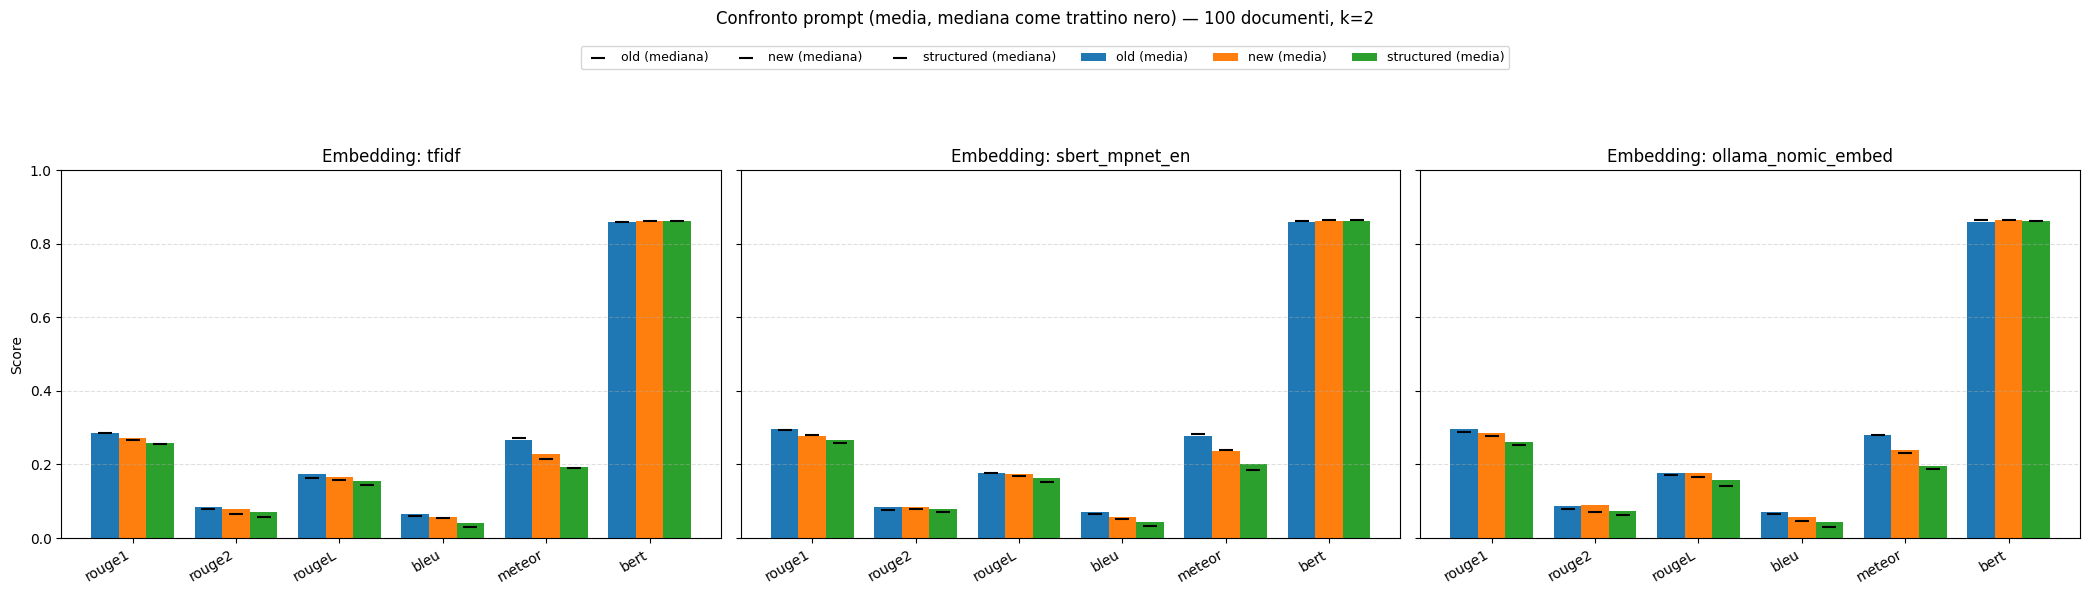

/var/folders/wc/lmk39_nj6vb165y5gdr58gqh0000gn/T/ipykernel_26576/815422090.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)


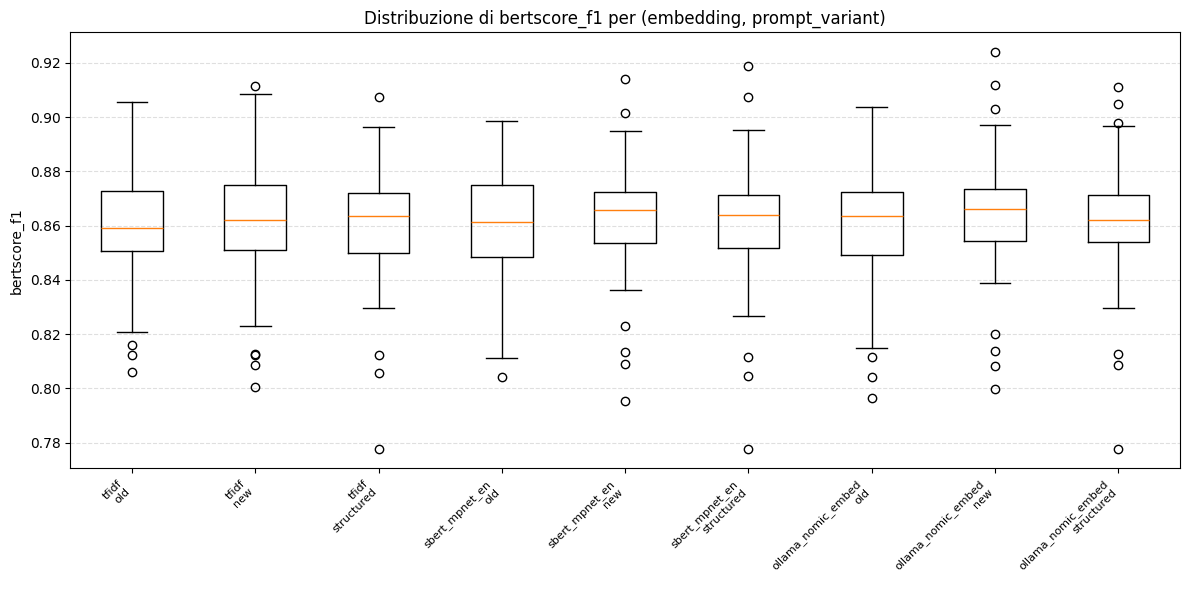

In [10]:
# =========================================================================
# Media e mediana per (embedding, prompt_variant) + visualizzazione grafica
# (usa full_comparison_df calcolato nella cella precedente)
# =========================================================================

import matplotlib.pyplot as plt
import numpy as np

# ---- tabelle di media e mediana ----
avg_table = (
    full_comparison_df
    .groupby(["embedding", "prompt_variant"])[_METRIC_COLS]
    .mean(numeric_only=True)
    .round(4)
)
median_table = (
    full_comparison_df
    .groupby(["embedding", "prompt_variant"])[_METRIC_COLS]
    .median(numeric_only=True)
    .round(4)
)

print("=== Medie ===")
print(avg_table)
print("\n=== Mediane ===")
print(median_table)

avg_table.to_csv("tfidf_vs_bert_prompt_variants_avg.csv")
median_table.to_csv("tfidf_vs_bert_prompt_variants_median.csv")
print("\nSalvati: tfidf_vs_bert_prompt_variants_avg.csv, tfidf_vs_bert_prompt_variants_median.csv")


# =========================================================================
# Visualizzazione: grafico a barre raggruppate, media (con mediana come punto)
# per un sottoinsieme di metriche chiave — una figura per ciascuna tecnica
# =========================================================================

_key_metrics = ["rouge1_f1", "rouge2_f1", "rougeL_f1", "bleu", "meteor", "bertscore_f1"]
_embeddings_order = list(dict.fromkeys(full_comparison_df["embedding"]))
_variants_order = ["old", "new", "structured"]

fig, axes = plt.subplots(1, len(_embeddings_order), figsize=(7 * len(_embeddings_order), 5), sharey=True)
if len(_embeddings_order) == 1:
    axes = [axes]

for ax, emb_name in zip(axes, _embeddings_order):
    x = np.arange(len(_key_metrics))
    width = 0.8 / len(_variants_order)

    for i, variant in enumerate(_variants_order):
        avg_vals = [avg_table.loc[(emb_name, variant), m] for m in _key_metrics]
        median_vals = [median_table.loc[(emb_name, variant), m] for m in _key_metrics]

        bars = ax.bar(x + i * width, avg_vals, width, label=f"{variant} (media)")
        # mediana sovrapposta come marker
        ax.scatter(x + i * width, median_vals, color="black", marker="_", s=100, zorder=3,
                   label=f"{variant} (mediana)" if ax is axes[0] else None)

    ax.set_xticks(x + width * (len(_variants_order) - 1) / 2)
    ax.set_xticklabels([m.replace("_f1", "").replace("bertscore", "bert") for m in _key_metrics],
                        rotation=30, ha="right")
    ax.set_title(f"Embedding: {emb_name}")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("Score")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=len(_variants_order) * 2, fontsize=9)
plt.suptitle(f"Confronto prompt (media, mediana come trattino nero) — {N_TEST_DOCS} documenti, k={TEST_K}",
             y=1.18)
plt.tight_layout()
plt.show()


# ---- boxplot: distribuzione completa di una metrica scelta, per (embedding, variant) ----
_metric_to_plot = "bertscore_f1"   # cambia con qualsiasi colonna in _METRIC_COLS

fig, ax = plt.subplots(figsize=(12, 6))
labels, data = [], []
for emb_name in _embeddings_order:
    for variant in _variants_order:
        vals = full_comparison_df[
            (full_comparison_df["embedding"] == emb_name) &
            (full_comparison_df["prompt_variant"] == variant)
        ][_metric_to_plot].dropna()
        labels.append(f"{emb_name}\n{variant}")
        data.append(vals.values)

ax.boxplot(data, labels=labels, showfliers=True)
ax.set_ylabel(_metric_to_plot)
ax.set_title(f"Distribuzione di {_metric_to_plot} per (embedding, prompt_variant)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()